In [22]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [96]:
df = pd.read_csv("primary/LUAD.clin.merged.picked.txt", sep="\t")
df.head()

,Hybridization REF,tcga-05-4245,tcga-05-4382,tcga-05-4384,tcga-05-4396,tcga-05-4402,tcga-05-4405,tcga-05-4410,tcga-05-4418,tcga-05-4427,...,tcga-nj-a4yg,tcga-nj-a4yi,tcga-nj-a4yp,tcga-nj-a4yq,tcga-nj-a55a,tcga-nj-a55o,tcga-nj-a55r,tcga-nj-a7xg,tcga-o1-a52j,tcga-s2-aa1a
0,Composite Element REF,value,value,value,value,value,value,value,value,value,...,value,value,value,value,value,value,value,value,value,value
1,years_to_birth,81,68,66,76,57,74,62,69,65,...,65,87,52,69,76,56,67,49,74,68
2,vital_status,0,0,0,1,1,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
3,days_to_death,NaN,NaN,NaN,303,244,NaN,NaN,274,NaN,...,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,1798,NaN
4,days_to_last_followup,730,607,426,NaN,NaN,610,0,NaN,791,...,2261,NaN,50,1432,15,13,603,617,NaN,513


In [97]:
df2 = pd.read_csv("primary/All_CDEs.txt", sep="\t")
df2.head()

,bcr_patient_barcode,tcga-05-4245,tcga-05-4382,tcga-05-4384,tcga-05-4396,tcga-05-4402,tcga-05-4405,tcga-05-4410,tcga-05-4418,tcga-05-4427,...,tcga-nj-a4yg,tcga-nj-a4yi,tcga-nj-a4yp,tcga-nj-a4yq,tcga-nj-a55a,tcga-nj-a55o,tcga-nj-a55r,tcga-nj-a7xg,tcga-o1-a52j,tcga-s2-aa1a
0,bcr_patient_uuid,03d09c05-49ab-4ba6-a8d7-e7ccf71fafd2,3434b91a-c05f-460f-a078-7b1bb6e7085d,9a50e7e4-831d-489f-87d2-979e987561cc,9f81c602-8afa-4588-b0b6-6e5a1a128d5a,722d6818-f1cb-49f4-b68a-fd0a31304681,f587c9ab-2949-4410-80d6-a050865d48aa,d28e465c-e553-4c53-8bb7-3d8199b9a8a5,d2c1e896-6886-4122-bb48-5fbcd3f641f4,78a24c56-576c-4245-bb42-6603b3d19897,...,7fd03220-531e-4ef8-beca-e9703e8c0ae1,2c03141e-a0bd-4e8d-91e4-9744d139ccce,42259aa6-c9f5-4309-a956-dbf930312f44,52df074f-a402-4b78-9472-f8eb268efded,b8b5ed35-b299-4c1e-9226-5ca055dc7a43,8ab8c4ba-311e-41d0-85ea-a0245aca1bdd,7c7d777b-bf00-4c24-97fc-922580d5605f,01e9888d-b5b9-48f1-8ba6-8a89af108a04,42432463-8e92-4f25-b72a-f03953527aa5,31458638-e19c-43e5-ab13-9c64b3b3681d
1,patient_id,4245,4382,4384,4396,4402,4405,4410,4418,4427,...,a4yg,a4yi,a4yp,a4yq,a55a,a55o,a55r,a7xg,a52j,aa1a
2,vital_status,alive,alive,alive,dead,dead,alive,alive,dead,alive,...,alive,dead,alive,alive,alive,alive,alive,alive,dead,alive
3,days_to_death,NaN,NaN,NaN,303,244,NaN,NaN,274,NaN,...,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,1798,NaN
4,days_to_last_followup,730,607,426,NaN,NaN,610,0,NaN,791,...,2261,NaN,50,1432,15,13,603,617,NaN,513


In [7]:
df2["bcr_patient_barcode"].unique()

array(['bcr_patient_uuid', 'patient_id', 'vital_status', 'days_to_death',
       'days_to_last_followup', 'additional_studies',
       'age_at_initial_pathologic_diagnosis',
       'anatomic_neoplasm_subdivision',
       'anatomic_neoplasm_subdivision_other', 'b_symptoms', 'bcr',
       'bcr_canonical_reason-2', 'bcr_canonical_reason-3',
       'bcr_canonical_reason', 'bcr_followup_barcode',
       'bcr_followup_uuid', 'bcr_patient_canonical_status', 'clinical_m',
       'clinical_n', 'clinical_stage', 'clinical_t', 'day_of_dcc_upload',
       'day_of_form_completion', 'days_to_birth', 'days_to_index',
       'days_to_initial_pathologic_diagnosis', 'days_to_last_known_alive',
       'days_to_psa', 'diagnosis', 'dlco_predictive_percent', 'drugs',
       'eastern_cancer_oncology_group', 'egfr_mutation_identified',
       'egfr_mutation_performed', 'egfr_mutation_result',
       'eml4_alk_translocation_identified',
       'eml4_alk_translocation_method',
       'eml4_alk_translocation_per

In [89]:
df2t = df2.set_index("bcr_patient_barcode").transpose()
df2t.head()

bcr_patient_barcode,bcr_patient_uuid,patient_id,vital_status,days_to_death,days_to_last_followup,additional_studies,age_at_initial_pathologic_diagnosis,anatomic_neoplasm_subdivision,anatomic_neoplasm_subdivision_other,b_symptoms,...,tissue_prospective_collection_indicator,tissue_retrospective_collection_indicator,tissue_source_site,tobacco_smoking_history,tumor_tissue_site,withdrawn,year_of_dcc_upload,year_of_form_completion,year_of_initial_pathologic_diagnosis,year_of_tobacco_smoking_onset
tcga-05-4245,03d09c05-49ab-4ba6-a8d7-e7ccf71fafd2,4245,alive,NaN,730,NaN,81,l-upper,NaN,NaN,...,no,yes,5,4,lung,false,2016,2012,2009,NaN
tcga-05-4382,3434b91a-c05f-460f-a078-7b1bb6e7085d,4382,alive,NaN,607,NaN,68,l-upper,NaN,NaN,...,no,yes,5,4,lung,false,2016,2012,2009,NaN
tcga-05-4384,9a50e7e4-831d-489f-87d2-979e987561cc,4384,alive,NaN,426,NaN,66,r-lower,NaN,NaN,...,no,yes,5,3,lung,false,2016,2012,2009,1963
tcga-05-4396,9f81c602-8afa-4588-b0b6-6e5a1a128d5a,4396,dead,303,NaN,NaN,76,r-lower,NaN,NaN,...,no,yes,5,3,lung,false,2016,2010,2006,1947
tcga-05-4402,722d6818-f1cb-49f4-b68a-fd0a31304681,4402,dead,244,NaN,NaN,57,r-lower,NaN,NaN,...,no,yes,5,1,lung,false,2016,2012,2007,NaN


In [90]:
df2t_stage = df2t[df2t["pathologic_stage"].isin(["stage i", "stage ia", "stage ib", "stage ii", "stage iia", "stage iib", "stage iiia", "stage iiib", "stage iv"])]
df2t_stage.head()

bcr_patient_barcode,bcr_patient_uuid,patient_id,vital_status,days_to_death,days_to_last_followup,additional_studies,age_at_initial_pathologic_diagnosis,anatomic_neoplasm_subdivision,anatomic_neoplasm_subdivision_other,b_symptoms,...,tissue_prospective_collection_indicator,tissue_retrospective_collection_indicator,tissue_source_site,tobacco_smoking_history,tumor_tissue_site,withdrawn,year_of_dcc_upload,year_of_form_completion,year_of_initial_pathologic_diagnosis,year_of_tobacco_smoking_onset
tcga-05-4245,03d09c05-49ab-4ba6-a8d7-e7ccf71fafd2,4245,alive,NaN,730,NaN,81,l-upper,NaN,NaN,...,no,yes,5,4,lung,false,2016,2012,2009,NaN
tcga-05-4382,3434b91a-c05f-460f-a078-7b1bb6e7085d,4382,alive,NaN,607,NaN,68,l-upper,NaN,NaN,...,no,yes,5,4,lung,false,2016,2012,2009,NaN
tcga-05-4384,9a50e7e4-831d-489f-87d2-979e987561cc,4384,alive,NaN,426,NaN,66,r-lower,NaN,NaN,...,no,yes,5,3,lung,false,2016,2012,2009,1963
tcga-05-4396,9f81c602-8afa-4588-b0b6-6e5a1a128d5a,4396,dead,303,NaN,NaN,76,r-lower,NaN,NaN,...,no,yes,5,3,lung,false,2016,2010,2006,1947
tcga-05-4402,722d6818-f1cb-49f4-b68a-fd0a31304681,4402,dead,244,NaN,NaN,57,r-lower,NaN,NaN,...,no,yes,5,1,lung,false,2016,2012,2007,NaN


In [93]:
sorted(list(df2t_stage["pathologic_stage"].unique()))

['stage i',
 'stage ia',
 'stage ib',
 'stage ii',
 'stage iia',
 'stage iib',
 'stage iiia',
 'stage iiib',
 'stage iv']

In [47]:
df2t_stage.groupby(by=["pathologic_stage", "gender"])["bcr_patient_uuid"].count().reset_index()

,pathologic_stage,gender,bcr_patient_uuid
0,stage i,female,5
1,stage ia,female,83
2,stage ia,male,51
3,stage ib,female,75
4,stage ib,male,65
5,stage ii,female,1
6,stage iia,female,21
7,stage iia,male,29
8,stage iib,female,34
9,stage iib,male,39


   pathologic_stage  gender  count  Percentage
0           stage i  female      5    0.972763
1          stage ia  female     83   16.147860
2          stage ia    male     51    9.922179
3          stage ib  female     75   14.591440
4          stage ib    male     65   12.645914
5          stage ii  female      1    0.194553
6         stage iia  female     21    4.085603
7         stage iia    male     29    5.642023
8         stage iib  female     34    6.614786
9         stage iib    male     39    7.587549
10       stage iiia  female     40    7.782101
11       stage iiia    male     34    6.614786
12       stage iiib  female      6    1.167315
13       stage iiib    male      5    0.972763
14         stage iv  female     12    2.334630
15         stage iv    male     14    2.723735


([0, 1, 2, 3, 4, 5, 6, 7, 8], <a list of 9 Text xticklabel objects>)

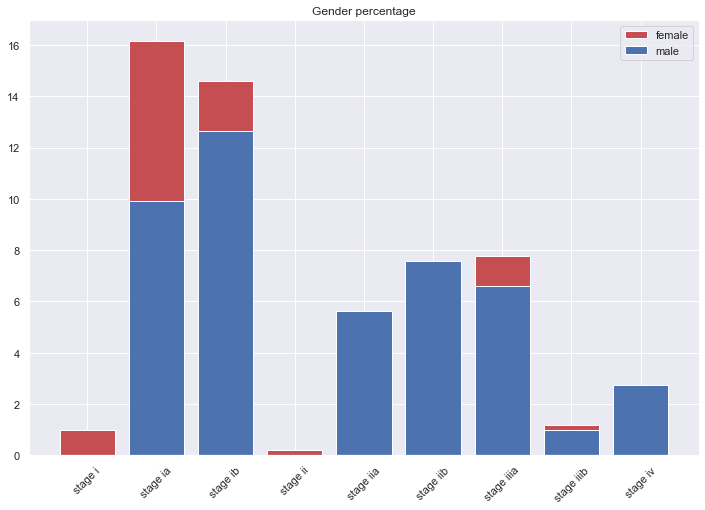

In [59]:
p_gender = df2t_stage.groupby(by=["pathologic_stage", "gender"])["bcr_patient_uuid"].count().reset_index().rename(columns={"bcr_patient_uuid":"count"})
p_gender['Percentage'] = 100 * p_gender['count']  / p_gender['count'].sum()
print(p_gender)
sns.set()
p_gender_female = p_gender[p_gender["gender"]=="female"]
p_gender_male = p_gender[p_gender["gender"]=="male"]

plt.figure(figsize=(12, 8))
plt.bar(p_gender_female["pathologic_stage"], p_gender_female["Percentage"], color='r')
plt.bar(p_gender_male["pathologic_stage"], p_gender_male["Percentage"], color='b')
plt.legend(("female", "male"))
plt.title("Gender percentage")
plt.xticks(rotation=45)

   pathologic_stage                              race  count  Percentage
0           stage i         black or african american      1    0.223714
1           stage i                             white      4    0.894855
2          stage ia                             asian      2    0.447427
3          stage ia         black or african american     18    4.026846
4          stage ia                             white    110   24.608501
5          stage ib                             asian      3    0.671141
6          stage ib         black or african american      8    1.789709
7          stage ib                             white    102   22.818792
8          stage ii         black or african american      1    0.223714
9         stage iia         black or african american      9    2.013423
10        stage iia                             white     39    8.724832
11        stage iib  american indian or alaska native      1    0.223714
12        stage iib                             asi

([0, 1, 2, 3, 4, 5, 6, 7, 8], <a list of 9 Text xticklabel objects>)

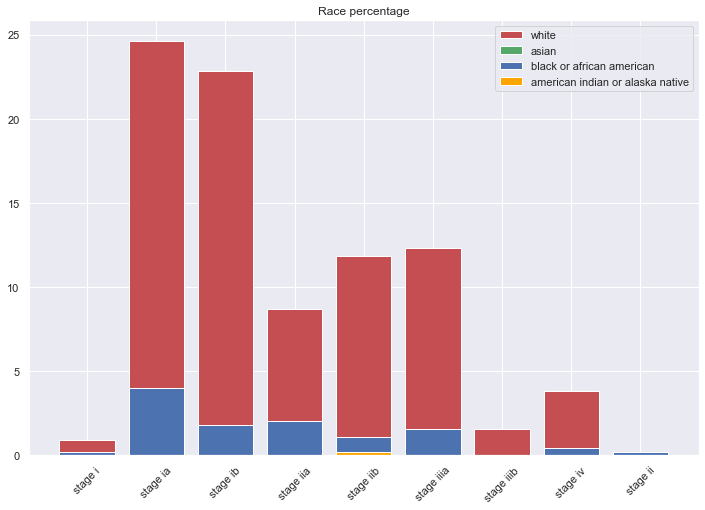

In [61]:
p_race = df2t_stage.groupby(by=["pathologic_stage", "race"])["bcr_patient_uuid"].count().reset_index().rename(columns={"bcr_patient_uuid":"count"})
p_race['Percentage'] = 100 * p_race['count']  / p_race['count'].sum()
print(p_race)
sns.set()
p_race_white = p_race[p_race["race"]=="white"]
p_race_asian = p_race[p_race["race"]=="asian"]
p_race_baa = p_race[p_race["race"]=="black or african american"]
p_race_aian = p_race[p_race["race"]=="american indian or alaska native"]


plt.figure(figsize=(12, 8))
plt.bar(p_race_white["pathologic_stage"], p_race_white["Percentage"], color='r')
plt.bar(p_race_asian["pathologic_stage"], p_race_asian["Percentage"], color='g')
plt.bar(p_race_baa["pathologic_stage"], p_race_baa["Percentage"], color='b')
plt.bar(p_race_aian["pathologic_stage"], p_race_aian["Percentage"], color="orange")
plt.legend(("white", "asian", "black or african american", "american indian or alaska native"))
plt.title("Race percentage")
plt.xticks(rotation=45)

In [83]:
p_both = df2t_stage.groupby(by=["pathologic_stage", "gender", "race"])["bcr_patient_uuid"].count().reset_index().rename(columns={"bcr_patient_uuid":"count"})
p_both['Percentage'] = 100 * p_both['count']  / p_both['count'].sum()
p_both[["gender", "race"]].drop_duplicates().values

array([['female', 'black or african american'],
       ['female', 'white'],
       ['female', 'asian'],
       ['male', 'black or african american'],
       ['male', 'white'],
       ['male', 'asian'],
       ['female', 'american indian or alaska native']], dtype=object)

([0, 1, 2, 3, 4, 5, 6, 7, 8], <a list of 9 Text xticklabel objects>)

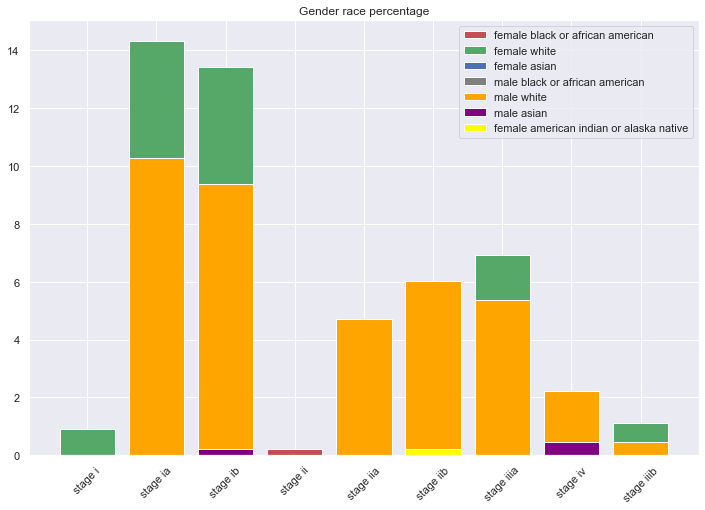

In [86]:
p_both = df2t_stage.groupby(by=["pathologic_stage", "gender", "race"])["bcr_patient_uuid"].count().reset_index().rename(columns={"bcr_patient_uuid":"count"})
p_both['Percentage'] = 100 * p_both['count']  / p_both['count'].sum()

plt.figure(figsize=(12, 8))
labels = []
colors = ["r", "g", "b", "grey", "orange",  "purple", "yellow"]
for idx, [_gender, _race] in enumerate(p_both[["gender", "race"]].drop_duplicates().values):
    _df = p_both[(p_both["gender"]==_gender) & (p_both["race"]==_race)]
    plt.bar(_df["pathologic_stage"], _df["Percentage"], color=colors[idx])
    labels.append(f"{_gender} {_race}")

plt.legend(labels)
plt.title("Gender race percentage")
plt.xticks(rotation=45)  

In [95]:
p_both.to_csv("p_both.csv")